In [1]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
DATASET_PATH = r"C:\Users\ADVAIT\Desktop\Sign\dataset\asl_alphabet_train\asl_alphabet_train"
IMG_SIZE = 128  # Image dimensions
BATCH_SIZE = 32  # Adjust based on available memory

In [3]:
# Data augmentation and normalization
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values (0-1)
    validation_split=0.2  # 80% training, 20% validation
)

# Training data generator
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation data generator
validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [4]:
# Print class labels
CATEGORIES = list(train_generator.class_indices.keys())
print(f"Categories: {CATEGORIES}")

Categories: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


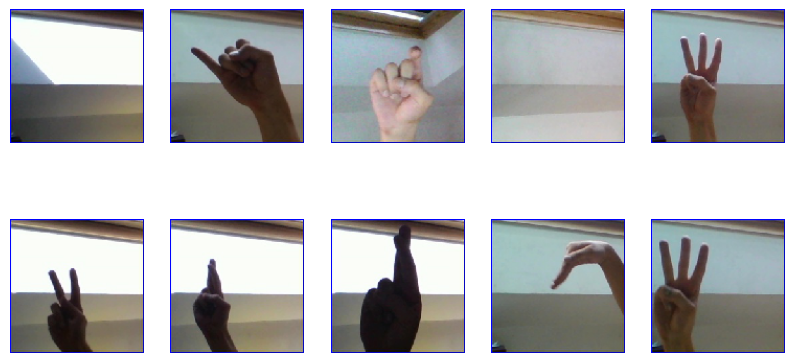

In [5]:
# Display some sample images from training data
x_batch, y_batch = next(train_generator)  # Get first batch
plt.figure(figsize=(10, 5))
for i in range(10):  
    plt.subplot(2, 5, i+1)
    plt.imshow(x_batch[i])
    plt.axis('off')
plt.show()

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
# Load MobileNetV2 (excluding top layers)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model (don't train its layers)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(len(CATEGORIES), activation='softmax')(x)  # Output layer

# Create new model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define Image Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load images using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=(128, 128), batch_size=32, class_mode='categorical'
)
validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH, target_size=(128, 128), batch_size=32, class_mode='categorical'
)


Found 87000 images belonging to 29 classes.
Found 87000 images belonging to 29 classes.


In [13]:
# Train the model
EPOCHS = 10
history = model.fit(train_generator, validation_data=validation_generator, epochs=EPOCHS, verbose=1)

# Save the new model
model.save(r"C:\Users\ADVAIT\Desktop\Sign\sign_language_model_mobilenet.h5")
print("Transfer Learning Model Saved Successfully!")

Epoch 1/10
2719/2719 [==============================] - 804s 295ms/step - loss: 0.5384 - accuracy: 0.8342 - val_loss: 0.1752 - val_accuracy: 0.9431
Epoch 2/10
2719/2719 [==============================] - 819s 301ms/step - loss: 0.2587 - accuracy: 0.9148 - val_loss: 0.1392 - val_accuracy: 0.9517
Epoch 3/10
2719/2719 [==============================] - 789s 290ms/step - loss: 0.2073 - accuracy: 0.9305 - val_loss: 0.1625 - val_accuracy: 0.9459
Epoch 4/10
2719/2719 [==============================] - 786s 289ms/step - loss: 0.1867 - accuracy: 0.9368 - val_loss: 0.1415 - val_accuracy: 0.9539
Epoch 5/10
2719/2719 [==============================] - 1063s 391ms/step - loss: 0.1678 - accuracy: 0.9437 - val_loss: 0.1440 - val_accuracy: 0.9553
Epoch 6/10
2719/2719 [==============================] - 785s 289ms/step - loss: 0.1555 - accuracy: 0.9468 - val_loss: 0.1448 - val_accuracy: 0.9549
Epoch 7/10
2719/2719 [==============================] - 785s 289ms/step - loss: 0.1498 - accuracy: 0.9488 - val

In [14]:
CONFIDENCE_THRESHOLD = 0.8  # Only accept predictions above 80% confidence

for img_name in os.listdir(TEST_DIR):
    img_path = os.path.join(TEST_DIR, img_name)

    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Predict the sign
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)  # Get the class index
    confidence = np.max(prediction)  # Get the confidence score
    predicted_label = CATEGORIES[predicted_class]

    # Only display predictions above the threshold
    if confidence >= CONFIDENCE_THRESHOLD:
        print(f"Image: {img_name} --> Predicted Sign: {predicted_label} (Confidence: {confidence:.2f})")
    else:
        print(f"Image: {img_name} --> Prediction Uncertain (Confidence: {confidence:.2f})")

1/1 [==============================] - 0s 496ms/step
Image: A_test.jpg --> Predicted Sign: A (Confidence: 1.00)
1/1 [==============================] - 0s 31ms/step
Image: B_test.jpg --> Predicted Sign: B (Confidence: 1.00)
1/1 [==============================] - 0s 31ms/step
Image: C_test.jpg --> Predicted Sign: C (Confidence: 1.00)
1/1 [==============================] - 0s 35ms/step
Image: D_test.jpg --> Predicted Sign: D (Confidence: 1.00)
1/1 [==============================] - 0s 35ms/step
Image: E_test.jpg --> Predicted Sign: E (Confidence: 1.00)
1/1 [==============================] - 0s 15ms/step
Image: F_test.jpg --> Predicted Sign: F (Confidence: 1.00)
1/1 [==============================] - 0s 33ms/step
Image: G_test.jpg --> Predicted Sign: G (Confidence: 1.00)
1/1 [==============================] - 0s 27ms/step
Image: H_test.jpg --> Predicted Sign: H (Confidence: 0.97)
1/1 [==============================] - 0s 26ms/step
Image: I_test.jpg --> Predicted Sign: I (Confidence: 1.00)


In [45]:
#latest working code

In [12]:
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras.models import load_model
import time
import pyttsx3  # Text-to-Speech

# Load the trained model
model = load_model("sign_language_model_mobilenet.h5")

# Define class labels (should match your training dataset order)
CATEGORIES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M",
              "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z",
              "space", "delete", "nothing"]

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(min_detection_confidence=0.7, min_tracking_confidence=0.7)

# Initialize Text-to-Speech
engine = pyttsx3.init()

# Open webcam
cap = cv2.VideoCapture(0)

sentence = ""  # Store predicted letters
last_pred = None  # Last predicted letter
last_time = time.time()  # Timer for letter confirmation
confidence_display = None  # Store confidence percentage

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Flip the frame horizontally (for natural interaction)
    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape

    # Convert frame to RGB (MediaPipe requires RGB)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect hands
    results = hands.process(rgb_frame)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Get bounding box around hand
            x_min, y_min, x_max, y_max = w, h, 0, 0

            for landmark in hand_landmarks.landmark:
                x, y = int(landmark.x * w), int(landmark.y * h)
                x_min = min(x_min, x)
                y_min = min(y_min, y)
                x_max = max(x_max, x)
                y_max = max(y_max, y)

            # Expand bounding box slightly
            padding = 20
            x_min = max(x_min - padding, 0)
            y_min = max(y_min - padding, 0)
            x_max = min(x_max + padding, w)
            y_max = min(y_max + padding, h)

            # Extract hand region
            hand_img = frame[y_min:y_max, x_min:x_max]

            if hand_img.shape[0] > 0 and hand_img.shape[1] > 0:
                # Resize and normalize image for the model
                hand_img = cv2.resize(hand_img, (128, 128))
                hand_img = hand_img / 255.0
                hand_img = np.expand_dims(hand_img, axis=0)

                # Predict sign language gesture
                predictions = model.predict(hand_img)
                predicted_index = np.argmax(predictions)
                predicted_label = CATEGORIES[predicted_index]
                confidence = predictions[0][predicted_index]

                # Show confidence score temporarily
                confidence_display = f"{predicted_label}: {confidence*100:.2f}%"

                # Adjust confidence threshold for better space/delete detection
                min_confidence = 0.8  # Default confidence threshold
                if predicted_label in ["space", "delete"]:
                    min_confidence = 0.6  # Allow lower confidence for space & delete

                # Check if prediction confidence is above threshold
                if confidence > min_confidence:
                    current_time = time.time()

                    if predicted_label != last_pred:
                        last_pred = predicted_label
                        last_time = current_time  # Reset timer

                    # Confirm prediction only if stable for 2 seconds
                    if current_time - last_time >= 2:
                        if predicted_label == "space":
                            sentence += " "  # Add space
                        elif predicted_label == "delete":
                            sentence = sentence[:-1]  # Remove last character
                        elif predicted_label != "nothing":
                            sentence += predicted_label  # Add letter
                        
                        last_pred = None  # Reset for next input
                        last_time = current_time
                        confidence_display = None  # Remove confidence display

                # Draw bounding box
                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

            # Draw hand landmarks
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    # Display confidence score temporarily
    if confidence_display:
        cv2.putText(frame, confidence_display, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Display recognized sentence
    cv2.putText(frame, "Sentence: " + sentence, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    cv2.imshow("Sign Language Recognition", frame)

    # Exit on pressing 'q' and speak sentence
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("Final Sentence:", sentence)
        engine.say(sentence)  # Speak sentence
        engine.runAndWait()
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

1/1 [==============================] - 0s 23ms/step
Final Sentence: HELLO
